In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz

In [5]:
nx = 81
L = 2.0
dx = L / (nx - 1)

C = 1.0
cfl = 0.8                # <= 1 (STABLE)
dt = cfl * dx / C
lam = C * dt / dx

Tf = 1.0
nt = int(Tf / dt)

In [7]:
x = np.linspace(0, L, nx)
u = np.ones(nx)

# square pulse
u[int(0.5/dx):int(1.0/dx)+1] = 2.0

In [8]:
r = np.zeros(nx-2)
c = np.zeros(nx-2)

c[0] = 1 - lam
c[1] = lam
r[0] = 1 - lam

T = toeplitz(c, r)

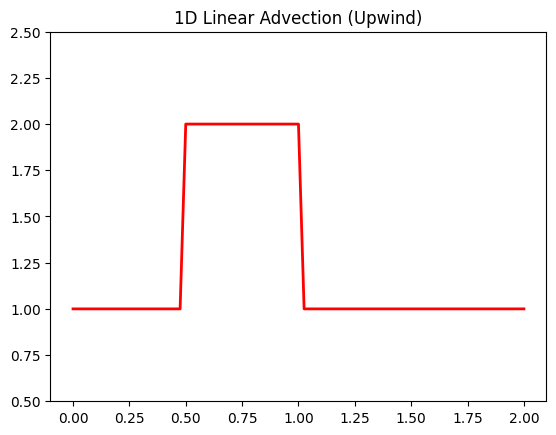

In [9]:
plt.ion()
fig, ax = plt.subplots()
line, = ax.plot(x, u, 'r-', lw=2)
ax.set_ylim(0.5, 2.5)
ax.set_title("1D Linear Advection (Upwind)")
plt.show()

In [11]:
for n in range(nt):
    u[1:-1] = T @ u[1:-1]

    # Dirichlet BCs (inflow)
    u[0] = 1.0
    u[-1] = 1.0

    line.set_ydata(u)
    plt.pause(0.01)

plt.ioff()
plt.show()